In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy as sp
from scipy.spatial.distance import pdist, squareform
import scipy.stats as stats

# Zadanie 1. 
Wczytaj macierz BIOM z zestawu environmental. Wykorzystując jawny broadcasting, oblicz odległość Euklidesa i Jaccarda między wszystkimi parami próbek w tym zestawie danych. Narysuj klastrowaną mapę ciepła i opisz swoje wnioski. Czy obie odległości wskazują na te same wnioski?

In [3]:
biom = pd.read_csv("data/environmental/biom.csv")

/tmp/ipykernel_472895/1469360016.py:1: DtypeWarning: Columns (4421,4422,4423,4424,4425,4426,4427,4428,4429,4430,4431,4432,4433,4434,4435,4436,4437,4438,4439,4440,4441,4442,4443,4444,4445,4446,4447,4448,4449,4450,4451,4452,4453,4454,4455,4456,4457,4458,4459,4460,4461,4462,4463,4464,4465,4466,4467,4468,4469,4470,4471,4472,4473,4474,4475,4476,4477,4478,4479,4480,4481,4482,4483,4484,4485,4486,4487,4488,4489,4490,4491,4492,4493,4494,4495,4496,4497,4498,4499,4500,4501,4502,4503,4504,4505,4506,4507,4508,4509,4510,4511,4512,4513,4514,4515,4516,4517,4518,4519,4520,4521,4522,4523,4524,4525,4526,4527,4528,4529,4530,4531,4532,4533,4534,4535,4536,4537,4538,4539,4540,4541,4542,4543,4544,4545,4546,4547,4548,4549,4550,4551,4552,4553,4554,4555,4556,4557,4558,4559,4560,4561,4562,4563,4564,4565,4566,4567,4568,4569,4570,4571,4572,4573,4574,4575,4576,4577,4578,4579,4580,4581,4582,4583,4584,4585,4586,4587,4588,4589,4590,4591,4592,4593,4594,4595,4596,4597,4598,4599,4600,4601,4602,4603,4604,4605,4606,4607,460

In [4]:
biom.index = biom.iloc[:, 0]
biom = biom.drop(columns=biom.columns[0])
biom.index.name = "sample_id"
biom = biom.map(lambda x: 0 if not isinstance(x, int) else x)

/home/oligus/miniconda3/envs/pp/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/oligus/miniconda3/envs/pp/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/oligus/miniconda3/envs/pp/lib/python3.14/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/oligus/miniconda3/envs/pp/lib/python3.14/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/oligus/miniconda3/envs/pp/lib/python3.

<Figure size 1000x1000 with 0 Axes>

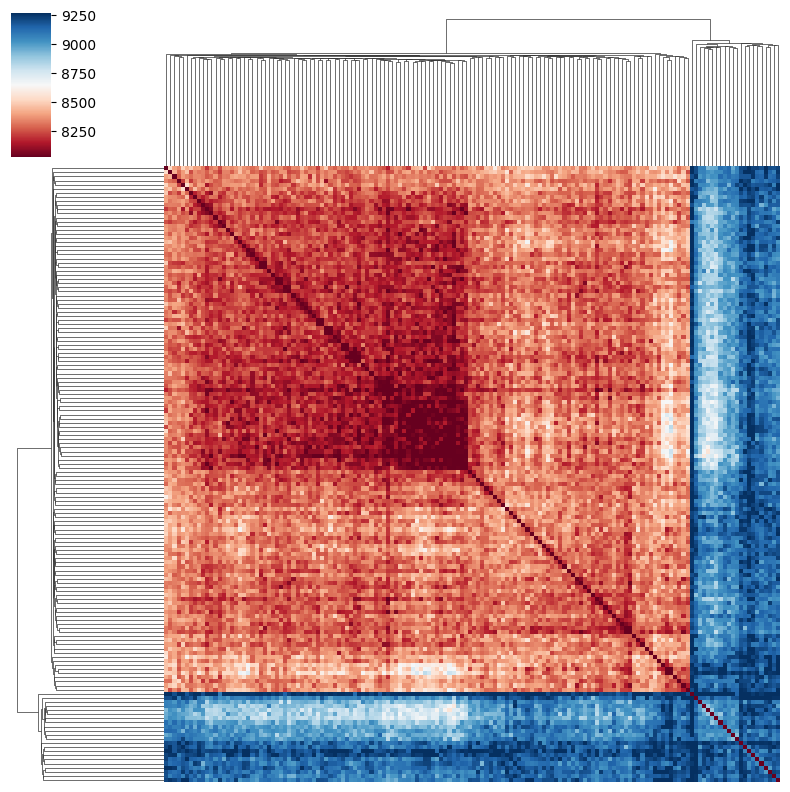

<Figure size 1000x1000 with 0 Axes>

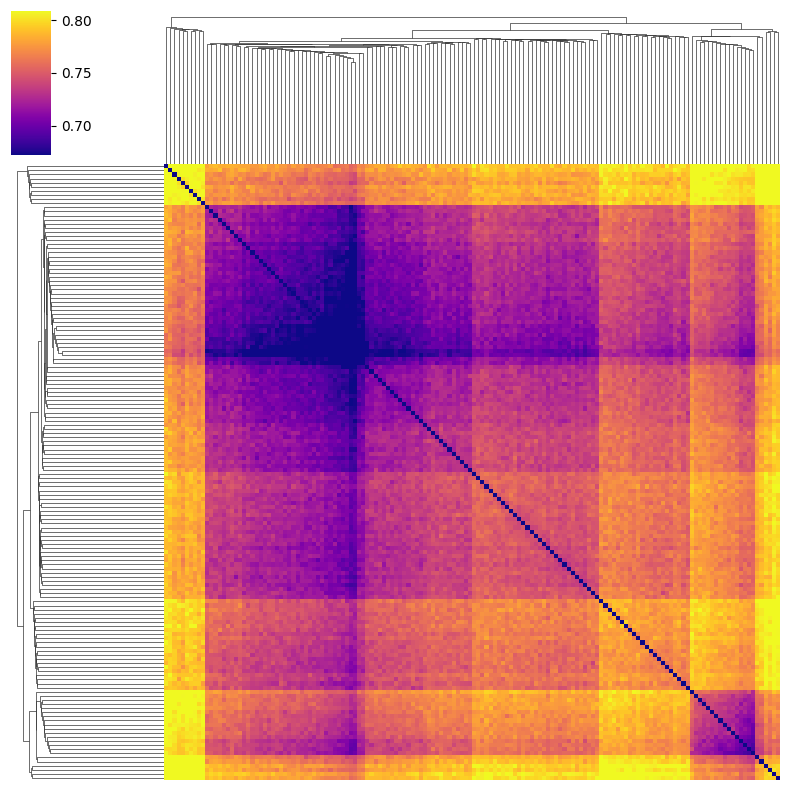

In [5]:
biom_numpy = biom.to_numpy()
n = biom_numpy.shape[0]

# macierze
eu_dist = np.zeros((n, n))
jac_dist = np.zeros((n, n))

for i in range(n):
    exp = biom_numpy[i, np.newaxis, :] 
    
    diff = exp - biom_numpy
    eu_dist[i, :] = np.sqrt(np.sum(diff**2, axis=1))
    
    inter = np.sum(np.minimum(exp, biom_numpy), axis=1)
    togh = np.sum(np.maximum(exp, biom_numpy), axis=1)
    
    with np.errstate(divide="ignore", invalid="ignore"):
        jacc = 1.0 - (inter / togh)
        jacc[np.isnan(jacc)] = 0.0 
        
    jac_dist[i, :] = jacc

eu_dist = (eu_dist + eu_dist.T) / 2.0
jac_dist = (jac_dist + jac_dist.T) / 2.0
np.fill_diagonal(eu_dist, 0.0)
np.fill_diagonal(jac_dist, 0.0)

lim = 150
eu_set = eu_dist[:lim, :lim]
jac_set = jac_dist[:lim, :lim]

# eu
plt.figure(figsize=(10, 10))
sns.clustermap(eu_set, cmap="RdBu", figsize=(8, 8), 
               robust=True, xticklabels=False, yticklabels=False
               )

# jacc
plt.figure(figsize=(10, 10))
sns.clustermap(jac_set, cmap="plasma", figsize=(8, 8), 
               robust=True, xticklabels=False, yticklabels=False
               )

plt.show()

# Zadanie 2.
W zestawie danych environmental każde stanowisko ma 90 próbek. Podziel macierz BIOM na stanowiska wykorzystując wbudowane funkcje NumPy.

In [11]:
smpls = 90
sites_n = biom_numpy.shape[0] // smpls

sites_list = np.vsplit(biom_numpy, sites_n)

print(f"liczba stanowisk: {len(sites_list)}")
print(f"kształt jednego stanowiska: {sites_list[0].shape}")

liczba stanowisk: 17
kształt jednego stanowiska: (90, 5372)


In [12]:
sites_tensor = biom_numpy.reshape(sites_n, smpls, biom_numpy.shape[1])

print(f"typ wyniku: {type(sites_tensor)}")
print(f"kształt tensora ze stanowiskami: {sites_tensor.shape}")

typ wyniku: <class 'numpy.ndarray'>
kształt tensora ze stanowiskami: (17, 90, 5372)


# Zadanie 3.

Wykorzystując *stacking*, złącz w jedną macierz macierze BIOM z próbek o numerach parzystych. Sprawdź czy średnia liczba wystąpień ASV jest statystycznie istotnie różna od liczby wystąpień powstałej ze złączenia macierzy próbek o numerach nieparzystych.

In [13]:
parzyste_list = [biom_numpy[i, :] for i in range(0, biom_numpy.shape[0], 2)]
nieparzyste_list = [biom_numpy[i, :] for i in range(1, biom_numpy.shape[0], 2)]

In [14]:
biom_parzyste = np.vstack(parzyste_list)
biom_nieparzyste = np.vstack(nieparzyste_list)

In [15]:
mean_parzyste = np.mean(biom_parzyste, axis=0)
mean_nieparzyste = np.mean(biom_nieparzyste, axis=0)

In [16]:
stat, p_value = stats.wilcoxon(mean_parzyste, mean_nieparzyste)

In [17]:
print(f"statystyka Wilcoxona: {stat:.2f}")
print(f"p: {p_value:.5e}\n")

statystyka Wilcoxona: 6992084.00
p: 5.16393e-02



In [27]:
if p_value < 0.05:
    print("wniosek: odrzucam hipotezę zerową, jest statystycznie istotna różnica w średniej liczbie wystąpień między próbkami.")
else:
    print("wniosek: nie ma podstaw do odrzucenia hipotezy zerowej, różnice między próbkami nie są statystycznie istotne")

wniosek: nie ma podstaw do odrzucenia hipotezy zerowej, różnice między próbkami nie są statystycznie istotne


# Zadanie 4.
Każda próbka w zestawie environmental była wykonywana w pięciu powtórzeniach. Dokonaj transformacji tabeli BIOM w taki sposób aby kolejne powtórzenia były reprezentowane jako kolejne macierze w trzecim wymiarze tensora BIOM. Sprawdź czy istnieją statystycznie istotne różnice w liczbie wystąpień między kolejnymi powtórzeniami.

In [20]:
n_rows, n_features = biom_numpy.shape
n_rep = 5
n_samples = n_rows // n_rep

In [21]:
biom_reshaped = biom_numpy.reshape(n_samples, n_rep, n_features)
tensor_biom = np.moveaxis(biom_reshaped, 1, 2)
print(f"kształt tensora BIOM: {tensor_biom.shape}")

kształt tensora BIOM: (306, 5372, 5)


In [22]:
reads_per_rep = np.sum(tensor_biom, axis=1)
rep1, rep2, rep3, rep4, rep5 = reads_per_rep.T

In [23]:
stat, p_value = stats.friedmanchisquare(rep1, rep2, rep3, rep4, rep5)

In [24]:
print(f"statystyka friedmana: {stat:.2f}")
print(f"p: {p_value:.5e}")

statystyka friedmana: 1.01
p: 9.08007e-01


In [26]:
if p_value < 0.05:
    print("wniosek: odrzucam hipotezę zerową, jest statystycznie istotna różnica w średniej liczbie wystąpień między próbkami.")
else:
    print("wniosek: nie ma podstaw do odrzucenia hipotezy zerowej, różnice między próbkami nie są statystycznie istotne")

wniosek: nie ma podstaw do odrzucenia hipotezy zerowej, różnice między próbkami nie są statystycznie istotne


# Zadanie 5.
Używając wyłącznie operacji NumPy oblicz entropię $H_{Shannon}$ z macierzy BIOM.

In [28]:
row_sums = np.sum(biom_numpy, axis=1, keepdims=True)

with np.errstate(divide="ignore", invalid="ignore"):
    p = biom_numpy / row_sums

log_p = np.log(p, out=np.zeros_like(p), where=(p > 0))

shannon = -np.nansum(p * log_p, axis=1)

print(shannon[:5])

[8.02998813 7.68471684 7.58419075 7.77354111 7.97419944]
